In [19]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

The matter Hamiltonian
$$
H_m = \frac{1}{2E_\nu}{\rm diag}(0,\Delta m_{21}^2,\Delta m_{31}^2)
$$
where $\Delta m_{21}^2=m_2^2-m_1^2$ and $\Delta m_{31}^2=m_3^2-m_1^2$.
One can transform $H_m$ into flavor basis by PMNS matrix
$$
U = 
\left(\begin{array}{ccc}
1 & 0 & 0\\
0 & \cos\theta_{23} & \sin\theta_{23}\\
0 & -\sin\theta_{23} & \cos\theta_{23}
\end{array}\right)\left(\begin{array}{ccc}
\cos\theta_{13} & 0 & \sin\theta_{13}e^{-i\delta}\\
0 & 1 & 0\\
-\sin\theta_{13}e^{i\delta} & 0 & \cos\theta_{13}
\end{array}\right)\left(\begin{array}{ccc}
\cos\theta_{12} & \sin\theta_{12} & 0\\
-\sin\theta_{12} & \cos\theta_{12} & 0\\
0 & 0 & 1
\end{array}\right)
$$
such that
$$
H_f = U H_m U^\dagger.
$$
The time evolution of any flavor state $v_f(t)$ is determined by the Schrodinger equation
$$
i \frac{d}{dt} v_f(t) = (H_f + V_f)v_f(t)
$$
where $V_f$ is the potential for matter effect. Given the man constitutent that can interact with is $\nu_e$ and electron, we have
$$
V_f = \sqrt{2}G_F \,{\rm diag}(n_e,0,0)
$$
where $n_e$ is the electron number density.
If the potential term is distance-dependent, one can cast the Schrodinger equation into
$$
i \frac{d}{dr} v_f(r) = [H_f + V_f(r)]v_f(r).
$$
We define a dimensionless variable $x=r/R_\odot$ such that the above differential equation can be rewritten as
$$
i\frac{d}{dx} v_f(x) = R_\odot[H_f+V(x)]v_f(x)\quad \to \quad v^\prime(x) = -i H_{\rm tot}(x) v_f(x)
$$
where $H_{\rm tot}(x)\equiv R_\odot[H_f+V(x)]$ and $R_\odot=6.96\times 10^{10}~{\rm cm}\approx 3.53\times 10^{21}~{\rm MeV^{-1}}$.

In [558]:
def matrixPMNS(theta13=8.57,theta12=33.44,theta23=49.2):
    # Mixing angles (radians)
    theta12 = np.radians(theta12)
    theta13 = np.radians(theta13)
    theta23 = np.radians(theta23)
    
    c12, s12 = np.cos(theta12), np.sin(theta12)
    c13, s13 = np.cos(theta13), np.sin(theta13)
    c23, s23 = np.cos(theta23), np.sin(theta23)
    
    # PMNS matrix (delta = 0)
    U = np.array([
        [c12 * c13, s12 * c13, s13],
        [-s12 * c23 - c12 * s23 * s13, c12 * c23 - s12 * s23 * s13, s23 * c13],
        [s12 * s23 - c12 * c23 * s13, -c12 * s23 - s12 * c23 * s13, c23 * c13]
    ])
    return U

U = matrixPMNS()

def matterHamiltonian(Ev,m21=7.53e-5,m31=2.4e-3):
    """
    This is not yet divided by Ev, output is MeV
    """
    return np.diag([0, m21, m31])*1e-12/2/Ev

def flavorHamiltonian(Ev):
    """
    This is divided by Ev
    """
    return U @ matterHamiltonian(Ev) @ U.T

In [151]:
# Define physical quantities
NA = 6.02e23 # Avogadro's number: 1/mol
GF = 1.166e-11 # Fermi constant, 1/MeV**2
perVol2CubicMeV = (1.973e-11)**3 # 1/cm**3 to MeV**3

# Load BP2000 data
R,Ne = np.loadtxt('BS05.txt',skiprows=6).T
# make interpolation
_ne_interp = make_interp_spline(R,Ne,k=1)
def ne(x):
    if R[0] <= x <= R[-1]:
        return 10**_ne_interp(x)*NA
    elif 0 <= x < R[0]:
        return 10**_ne_interp(R[0])*NA
    else:
        return 0

def ne_natural(x):
    """
    1/cm**3 to MeV**3
    """
    return ne(x)*np.sqrt(2)*GF*perVol2CubicMeV

Text(0, 0.5, '$n_e~[{\\rm cm}^{-3}]$')

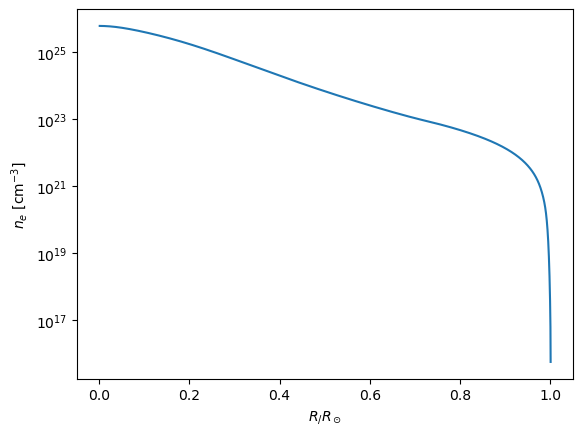

In [821]:
plt.plot(R,10**Ne*NA)
#plt.plot(rList,[ne(x) for x in rList],'--')
plt.yscale('log')
plt.xlabel(r'$R_/R_\odot$')
plt.ylabel(r'$n_e~[{\rm cm}^{-3}]$')

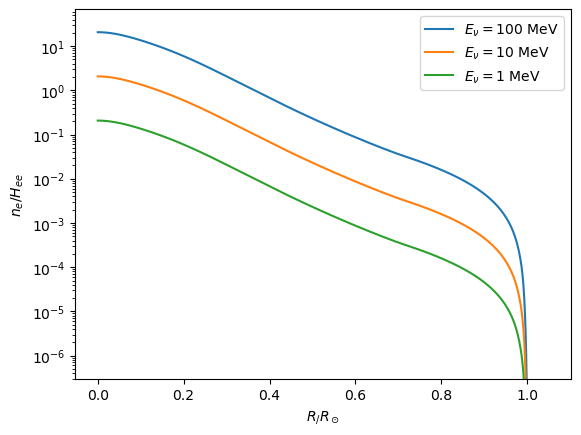

In [874]:
rList = np.linspace(0,1.05,1000)
#plt.plot([rList[0],rList[-1]],[flavorHamiltonian(1)[0,0],flavorHamiltonian(1)[0,0]],label=r'$E_\nu=1$ MeV')
plt.plot(rList,[ne_natural(x)/flavorHamiltonian(100)[0,0] for x in rList],label=r'$E_\nu=100$ MeV')
plt.plot(rList,[ne_natural(x)/flavorHamiltonian(10)[0,0] for x in rList],label=r'$E_\nu=10$ MeV')
plt.plot(rList,[ne_natural(x)/flavorHamiltonian(1)[0,0] for x in rList],label=r'$E_\nu=1$ MeV')

plt.yscale('log')
plt.xlabel(r'$R_/R_\odot$')
plt.ylabel(r'$n_e/H_{ee}$')
plt.ylim(3e-7,)
plt.legend()

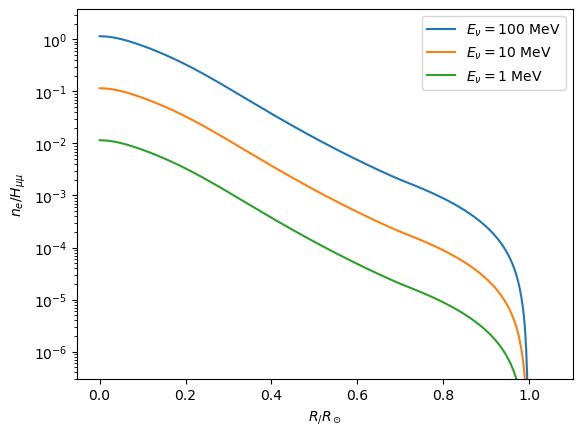

In [876]:
plt.plot(rList,[ne_natural(x)/flavorHamiltonian(100)[1,1] for x in rList],label=r'$E_\nu=100$ MeV')
plt.plot(rList,[ne_natural(x)/flavorHamiltonian(10)[1,1] for x in rList],label=r'$E_\nu=10$ MeV')
plt.plot(rList,[ne_natural(x)/flavorHamiltonian(1)[1,1] for x in rList],label=r'$E_\nu=1$ MeV')
plt.yscale('log')
plt.xlabel(r'$R_/R_\odot$')
plt.ylabel(r'$n_e/H_{\mu\mu}$')
plt.ylim(3e-7,)
plt.legend()

In [564]:
def totalH(Ev,x):
    """
    Dimensionless H_tot at x with neutrino energy Ev
    """
    return (flavorHamiltonian(Ev) + np.diag([ne_natural(x),0,0]))*3.53e21

As `solve_ivp` cannot solve complex system ODE, one needs to decompose the ODE into real and imaginary parts and solve them together.
Let
$$
H_{\rm tot} = A + i B 
$$
and
$$
v_f = u_f + iw_f,
$$
we can decompose the original 3 complex coupled ODEs into
\begin{align*}
\begin{cases}
u_{f}^{\prime}(x)=A(x)w_{f}(x)+B(x)u_{f}(x) & \textrm{real part}\\
w_{f}^{\prime}(x)=-A(x)u_{f}(x)+B(x)w_{f}(x) & \textrm{imaginary part}
\end{cases}
\end{align*}
where each part contains 3 real coupled ODEs and total 6. Solve them simutaneously one obtains $v_f$ at any $x$ for a given $E_\nu$.

In [580]:
def coupled_ODEs(x,y,Ev):
    Htot = totalH(Ev,x)
    A = Htot.real #,Htot.imag
    u,w = y[:3],y[3:]
    du_dx = A @ w #+ B @ u
    dw_dx = -A @ u # + B @ w
    return np.concatenate([du_dx, dw_dx])

In [861]:
#v0_complex = np.array([1.0, 0.0, 0.0], dtype=np.complex128)
ini_prob = [1,0,0] # e,mu,tau initial prob
ini_phase = [0,0,0]
y0 = np.concatenate([np.sqrt(ini_prob),ini_phase])

x_span = (0.002, 0.003)
x_eval = np.linspace(*x_span, 3000)

sol = solve_ivp(coupled_ODEs, x_span, y0, t_eval=x_eval, args=(0.01,), rtol=1e-6, atol=1e-9)

# 重組複數解
u_sol = sol.y[:3]
w_sol = sol.y[3:]
v_sol = u_sol + 1j * w_sol

# 機率
P_e = np.abs(v_sol[0])**2
P_mu = np.abs(v_sol[1])**2
P_tau = np.abs(v_sol[2])**2
P_tot = P_e+P_mu+P_tau

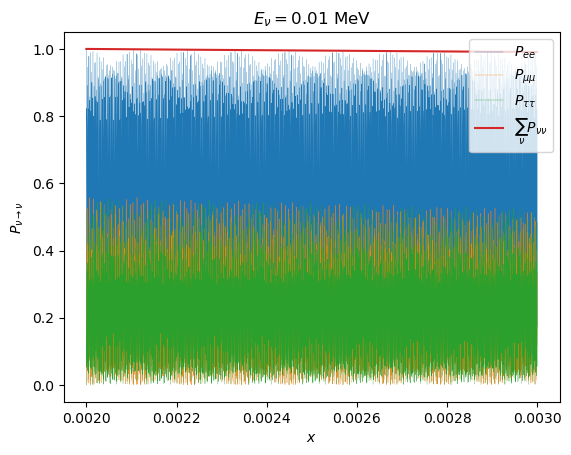

In [863]:
plt.plot(x_eval, P_e, label=r'$P_{ee}$',linewidth=0.25)
plt.plot(x_eval, P_mu, label=r'$P_{\mu\mu}$',linewidth=0.25)
plt.plot(x_eval, P_tau, label=r'$P_{\tau\tau}$',linewidth=0.25)
plt.plot(x_eval, P_tot, label=r'$\sum_\nu {P_{\nu\nu}}$')
plt.xlabel(r'$x$')
plt.ylabel(r'$P_{\nu\to\nu}$')
#plt.ylim(0,1)
plt.legend(loc='upper right')
plt.title(r'$E_\nu = 0.01$ MeV')
plt.savefig('Ev001MeV_P_short.pdf',bbox_inches='tight')


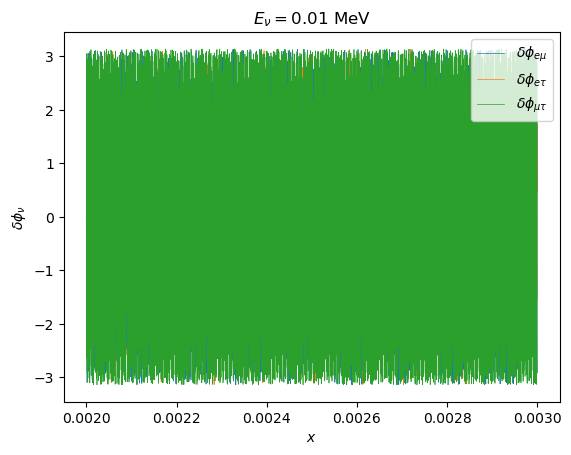

In [865]:
plt.plot(x_eval, np.angle(np.exp(1j*(np.angle(v_sol[0])-np.angle(v_sol[1])))), label=r'$\delta \phi_{e\mu}$',linewidth=0.5,zorder=3)
plt.plot(x_eval, np.angle(np.exp(1j*(np.angle(v_sol[0])-np.angle(v_sol[2])))), label=r'$\delta \phi_{e\tau}$',linewidth=0.5)
plt.plot(x_eval, np.angle(np.exp(1j*(np.angle(v_sol[1])-np.angle(v_sol[2])))), label=r'$\delta \phi_{\mu\tau}$',linewidth=0.5,zorder=4)
#plt.plot(x_eval, P_mu, label=r'$P_{\mu\mu}$',linewidth=0.25)
#plt.plot(x_eval, P_tau, label=r'$P_{\tau\tau}$',linewidth=0.25)
#plt.plot(x_eval, P_tot, label=r'$\sum_\nu {P_{\nu\nu}}$')
plt.xlabel(r'$x$')
plt.ylabel(r'$\delta\phi_{\nu}$')
#plt.ylim(0,1)
plt.legend(loc='upper right')
plt.title(r'$E_\nu = 0.01$ MeV')
plt.savefig('Ev0.01MeV_phi_short.pdf',bbox_inches='tight')
